<img src="https://www.ikiam.edu.ec/img/logo-ikiam-grey.png" width=300 height=240 />

# EXAMEN PARCIAL PYTHON
    

## GBI6-2021II: BIOINFORMÁTICA

**Carrera Barona, Juan Carlos** <--- CAMBIE POR LOS QUE CORRESPONDA A SUS DATOS

**25-02-2021**

<font color='red'>NO AGREGUE NUEVAS CELDAS, UTILICE ÚNICAMENTE LAS QUE ESTÁN CREADAS</font>


### REQUERIMIENTOS PARA EL EXAMEN
Para este examen se requiere dos documentos: 

1. Archivo ```miningscience.py``` donde tendrá dos funciones:

2. Archivo ```2021II_GBI6_ExamenParcialPython``` donde se llamará las funciones y se obtendrá resultados.

## Ejercicio 1 [2 puntos]
Cree el archivo ```miningscience.py``` con las siguientes dosfunciones:
    
i. ```download_pubmed```: para descargar la data de PubMed utilizando el **ENTREZ** de Biopython. El parámetro de entrada para la función es el ```keyword```. 
    
ii. ```mining_pubs```: esta función debe utilizar el módulo **re** y utilizar el párametro ```tipo``` para realizar lo siguiente:
        
* Si el tipo es "DP" recupera el año de publicación del artículo. El retorno es un *dataframe* con el **PMID** y el **DP_year**.
      
* Si el tipo es "AU" recupera el número de autores por **PMID**. El retorno es un *dataframe* con el **PMID** y el **num_auth**. 
      
* Si el tipo es "AD" recupera el conteo de autores por país. El retorno es un *dataframe* con el **country** y el **num_auth**. 

* *Puede utilizar un ```if``` dentro de la función.* 

* *Cree un docstring para cada función.* 

Luego de crear las funciones, cargue el módulo ```miningscience``` como ```msc``` e imprima docstring de cada función.




In [1]:
# Escriba aquí su código para el ejercicio 1
import miningscience as msc 
help (msc)



Help on module miningscience:

NAME
    miningscience

FUNCTIONS
    download_pubmed(keyword)
        Descarga la data de PubMed utilizando el ENTREZ de Biopython
        la funcion devuelve el # de articulos y los IDs
    
    mining_pubs(PMIDs, tipo)
        esta función debe utilizar el módulo re y utilizar el párametro tipo para realizar lo siguiente:
        Si el tipo es "DP" recupera el año de publicación del artículo. El retorno es un dataframe con el PMID y el DP_year.
        Si el tipo es "AU" recupera el número de autores por PMID. El retorno es un dataframe con el PMID y el num_auth.
        Si el tipo es "AD" recupera el conteo de autores por país. El retorno es un dataframe con el country y el num_auth.

FILE
    c:\users\jah guide\desktop\sexto\bioinformatica_moises\semana_3\miningscience.py





## Ejercicio 2 [1 punto]


Utilice la función ```download_pubmed``` para descargar la data con el keyword ```Ecuador proteomics``` e imprima lo siguiente: 

```python
'El número de artículos es: xx' # xx corresponde al número de artículos recuperados

'El PMID del primer artículo es: xxxxxxxx' # xxxxxxxx corresponde al ID del artículo en PUDMED

```

In [2]:
# Escriba aquí su código para el ejercicio 2
import miningscience as msc 
artgem,artid = msc.download_pubmed("Ecuador genomics")
print ("El número de artículos es: " , artgem) 
print ("El PMID del primer artículo es: " ,artid [0])


El número de artículos es:  193
El PMID del primer artículo es:  35121084


## Ejercicio 3 [1 punto]

Utilice la función ```mining_pubs``` para crear los siguientes dataframes: 

* pub_year

* pub_authors

* coutries

Muestre los dos primeros y los dos últimos registros de cada dataframe. 

In [3]:
# Escriba aquí su código para el ejercicio 3 
import miningscience as msc 
artgem,artid = msc.download_pubmed("Ecuador genomics")
pub_year= msc.mining_pubs(artid, "DP")
print(pub_year.iloc[[0,1,-2,-1]])
pub_authors= msc.mining_pubs(artid, "AU")
print(pub_authors.iloc[[0,1,-2,-1]])
coutries=msc.mining_pubs(artid, "AD")
print(coutries.iloc[[0,1,-2,-1]])

         PMID  year
0    35121084  2022
1    35120121  2022
191  17187350  2007
192   8661097  1996
         PMID  Autores
0    35121084       12
1    35120121       14
191  17187350        1
192   8661097        9
              Pais  Autores
0    United States       12
1    United States       14
191  United States        1
192  United States        9


## Ejercicio 4 [2 puntos]

Realice la visualización de los datos del ejercicio 3. 

* ```pubyear```: utilizando el conteo artículos por año, calcule la media y la desviación estandar (asumiendo que la distribución es normal). Realice un gráfico de la distribución normal de sus datos. Coloque el título, leyenda de los ejes "x" e "y", y la leyenda de la curva (utilice las expresiones matemáticas tipos latex de ser necesario). 

* ```pub_authors```: realice un boxplot del conteo de autores por artículo. Coloque las leyendas adecuadas para cada eje y el título.  

* ```countries```: realice una nube de puntos (adaptación de su tarea), resalte al menos 3 países con flechas. Coloque las leyendas adecuadas para cada eje y el título. 


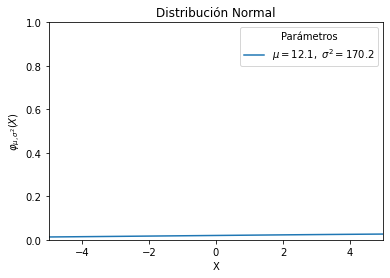

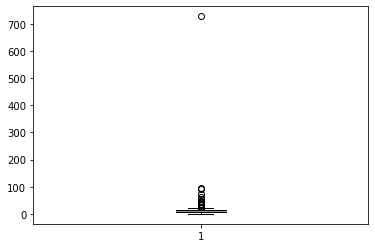

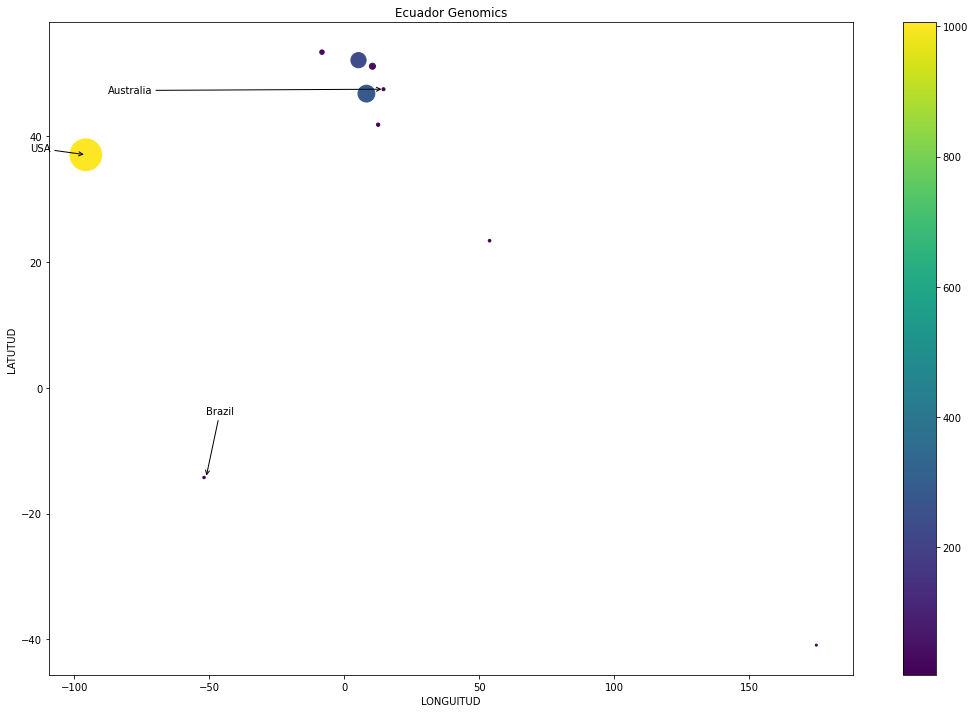

In [4]:
# Escriba aquí su código para el ejercicio 4
# AGRUPAMOS VARIABLES POR AÑO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import math
import seaborn as sns
import pandas as pd
import scipy.stats as stats

pubyearagg= pub_year.groupby("year")
pubyearagg=pubyearagg.count()

mean= pubyearagg.mean()
variance= pubyearagg.var()
variance

x = np.linspace(mean - 3*math.sqrt(variance), mean + 3*math.sqrt(variance), 100)
sigma = math.sqrt(variance)
label = '$\mu = %.1f, \ \sigma^2=%.1f$' %(mean, variance)
y_norm = stats.norm.pdf(x, mean, sigma)
plt.plot(x, y_norm, label=label)
plt.xlim(-5,5)
plt.ylim(0,1)
plt.xlabel('X')
plt.ylabel('$φ_{μ,σ^2}(X)$')
plt.title('Distribución Normal')
plt.legend(title = "Parámetros")
plt.show()
fig=plt.figure()
plt.boxplot(pub_authors["Autores"]) 
plt.show()
import csv 
coutriest=coutries.groupby("Pais")
coutriest=coutriest.sum()
coutriest
diccoordenadas = {}
with open("direcc.csv") as f1:
    csvr = csv.DictReader(f1)
    for row in csvr:
        #print(row)
        diccoordenadas[row['name']] = [float(row['latitude']), 
                                       float(row['longitude'])]
contador= []
long= []
latt= []
for pais in coutriest.index:
    if pais in diccoordenadas:
        long.append(diccoordenadas[pais][1])
        latt.append(diccoordenadas[pais][0])
        contador.append(coutriest.loc[pais])
fig= plt.figure()
plt.scatter(long, latt, s = contador, c=contador)
plt.colorbar()
ard = dict(arrowstyle="->")


plt.annotate('Brazil', xy = (-51.192528,-14.235004), 
               xytext = (-51.192528,-4.235004), arrowprops= ard)

plt.annotate('Australia', xy = (14.550072, 47.516231), 
               xytext = (-87.6847, 46.8369), arrowprops= ard)
plt.annotate('USA', xy = (-95.712891, 37.09024), 
               xytext = (-116.33, 37.61), arrowprops= ard)

params = plt.gcf()

params = plt.gcf()
plSize = params.get_size_inches()
params.set_size_inches( (plSize[0] * 3, plSize[1] * 3) )
plt.xlabel("LONGUITUD")
plt.ylabel("LATUTUD")
plt.title("Ecuador Genomics")
plt.show()
plt.show()



## Ejercicio 5 [1 punto]

Interprete los resultados del **ejercicio 4**
## Python devuelve valores de vacianza muy altos (170,2), estadisticamente cuando los valores son elevados nos muestra que los datos estan dispersos, la media por su parte es de 12, mostrando que los años de publicaciones para ecuador genomics no es alto, en cuanto a la interpretacion estadistica la media no muestra ser armonica, pues no hay una distribucion central de datos.  Por lo tanto la media no es representativa 

## Para la grafica del boxplot. Los bloxplot nos permiten identificar 5 medidas descritivas. En el la grafica obtenida no se puede observar de forma concluyente las 5 medidas descriptivas como tal. La parte que si nos podemos dar cuenta es que la mayoria de los valores estan por encima de media que es 12, mostrandose como valores atipicos la mayoria de los datos que se obtuviron. 

### Escriba la respuesta del ejercicio 5


## Ejercicio 6 [2 puntos]

Para algún gen de interés, realice lo siguiente: 

1. Una búsqueda en la página del [NCBI nucleotide](https://www.ncbi.nlm.nih.gov/nucleotide/).

2. Descargue el ```Accession List``` de su búsqueda.

3. Cargue el ```Accession List``` en este notebook y haga una descarga de la data tipo ```genbank``` utilizando los diez primeros IDs de accesión. 

4. Arme un árbol filogenético para los resultados del paso 3.

5. Interprete el árbol del paso 4. 

In [52]:
# Escriba aquí su código para el ejercicio 6
from Bio import Entrez
from Bio import SeqIO
with open ("sequence.seq") as f1: 
    ids= ""
    for i in range (10):
        ids=ids+f1.readline().rsplit()[0]+","
ids=ids[:-1]

Entrez.email = "juan.carrera@est.ikiam.edu.ec" 
with Entrez.efetch( db="nucleotide", rettype="gb", retmode="text", id=ids 
                  ) as handle: 
    print(handle.url)
records = SeqIO.parse("sequence.gb", "genbank") 
count = SeqIO.write(records, "sequence.fasta", "fasta") 

from Bio.Align.Applications import ClustalwCommandline
import os
clustalw_exe = r"C:\Program Files (x86)\ClustalW2\clustalw2.exe"
clustalw_cline = ClustalwCommandline(clustalw_exe, infile = "sequence.fasta")
assert os.path.isfile(clustalw_exe), "Clustal_W executable is missing or not found"
stdout, stderr = clustalw_cline()
print(clustalw_cline)
from Bio import AlignIO
ClustalAlign = AlignIO.read("sequence.aln", "clustal")
from Bio import Phylo
with open("sequence.aln","r") as aln: 
    alignment = AlignIO.read(aln,"clustal")
print(type(alignment))
from Bio.Phylo.TreeConstruction import DistanceCalculator 
calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
constructor = DistanceTreeConstructor(calculator)
rag2_tree = constructor.build_tree(alignment)
rag2_tree.rooted = True
Phylo.write(rag2_tree, "sequence.xml", "phyloxml")
import matplotlib
fig = plt.figure(figsize=(50, 60), dpi=200) # create figure & set the size 
matplotlib.rc('font', size=12)              # fontsize of the leaf and node labels 
matplotlib.rc('xtick', labelsize=10)       # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=10)       # fontsize of the tick labels
axes = fig.add_subplot(1, 1, 1)
Phylo.draw(rag2_tree, axes=axes)
fig.savefig("arbol.pdf")


https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nucleotide&rettype=gb&retmode=text&id=MF098562.1%2CMF098561.1%2CMF098560.1%2CMF769711.1%2CMF769710.1%2CMF769709.1%2CMF769708.1%2CMF769707.1%2CMF769706.1%2CMF769705.1&tool=biopython&email=juan.carrera%40est.ikiam.edu.ec
"C:\Program Files (x86)\ClustalW2\clustalw2.exe" -infile=sequence.fasta
<class 'Bio.Align.MultipleSeqAlignment'>


**Escriba aquí la interpretación del árbol**
##  MF769707.1  o BRCA2 es el gen ancestro dentro del arbol filogenetico el mismo tiene que ver cpn el  cáncer de seno 2, son una familia de genes que producen proteínas que reparan daños en el ácido desoxirribonucleico (ADN) se ha tomado a este gen como gen progenitor (BRCA2), punto de ramificación Inner3 se encuentra el ancestro común más reciente para  . F098560.1, MF098561.1, MF098562.1  son las ramas principales o la desendencia hasta ahora encontrada de estos genes 



## Ejercicio 7 [1 punto]


1. Cree en GitHub un repositorio de nombre ```GBI6_ExamenPython```. 
2. Cree un archivo ```Readme.md``` que debe tener lo siguiente: 
- Datos personales
- Características del computador
- Versión de Python/Anaconda y de cada uno de los módulos/paquetes y utilizados
- Explicación de la data utilizada

3. Cree un directorio de nombre ```data``` donde deben estar guardado la data utilizada 
4. Realice al menos 1 control de la versión (commits) por cada ejercicio (del 1 al 6), con un mensaje que inicie como: 

```sh 
Carlitos Alimaña ha realizado .....  
```